# Notebook 04: Model Development & Hyperparameter Tuning

## 1. Overview
This notebook covers **Phase 4: Model Development and Hyperparameter Tuning** of the Customer Support Ticket Classification pipeline. 

We will load our raw ticket dataset, perform a stratified sub-sampling to **50,000 tickets**, split it into Train (70%), Validation (15%), and Test (15%) partitions, and preprocess the text. We will then fit our feature representation (TF-IDF) solely on the training data to avoid data leakage and train multiple machine learning models:
1. **Baseline**: Multinomial Naive Bayes
2. **Logistic Regression** (GPU-accelerated via RAPIDS cuML)
3. **Support Vector Machine (SVC)** (GPU-accelerated via RAPIDS cuML)
4. **XGBoost** (GPU-accelerated via native CUDA)

We will tune hyperparameters using K-Fold cross-validation, show visual progress bars using `tqdm`, select the champion model based on validation F1-macro score, and serialize the best estimator, vectorizer, and label encoder.

## 2. Environment Verification & Imports
First, we import our dependencies and verify that the GPU is available for cuML and XGBoost.

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tqdm import tqdm
from sklearn.metrics import classification_report, f1_score, accuracy_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder

# Ensure project root is in path
sys.path.append(os.path.abspath(".."))

# Check GPU and CUDA status
try:
    import cupy as cp
    import cuml
    gpu_avail = True
    print(f"[SUCCESS] RAPIDS cuML is available (v{cuml.__version__}).")
    print(f"[SUCCESS] Cupy is available (v{cp.__version__}).")
    print(f"Active GPU Device: {cp.cuda.Device(0)}")
except ImportError:
    gpu_avail = False
    print("[WARNING] RAPIDS cuML not found. Pipeline will fall back to CPU-based scikit-learn.")

[SUCCESS] RAPIDS cuML is available (v26.06.00).
[SUCCESS] Cupy is available (v14.1.1).
Active GPU Device: <CUDA Device 0>


## 3. Data Splitting & Caching
We use the modular `load_and_split_data` utility. It handles train/validation/test partitioning and text cleaning, saving the preprocessed files to `data/processed/` so subsequent runs load instantly.

In [3]:
from src.config import RAW_DATA_PATH, TEXT_COL, TARGET_COL, SAMPLE_SIZE
from src.train import load_and_split_data

print(f"Configured Sample Size: {SAMPLE_SIZE}")

# Load and split (will preprocess and cache if running for the first time)
train_df, val_df, test_df = load_and_split_data(str(RAW_DATA_PATH))

print(f"\nSplit Dimensions:")
print(f"- Train Set: {train_df.shape[0]} rows")
print(f"- Validation Set: {val_df.shape[0]} rows")
print(f"- Test Set: {test_df.shape[0]} rows")


2026-06-11 20:56:29 | train | INFO | RAPIDS cuML is available. GPU acceleration will be used for modeling.


2026-06-11 20:56:29 | train | INFO | XGBoost is available.
2026-06-11 20:56:29 | train | INFO | Loading preprocessed Train/Val/Test splits from cache...


Configured Sample Size: 50000


2026-06-11 20:56:30 | timer | INFO | Function 'load_and_split_data' completed in 0.6420 seconds



Split Dimensions:
- Train Set: 35000 rows
- Validation Set: 7500 rows
- Test Set: 7500 rows


Let's check target stratification across the splits to make sure our train, validation, and test datasets represent the ticket categories in identical proportions.

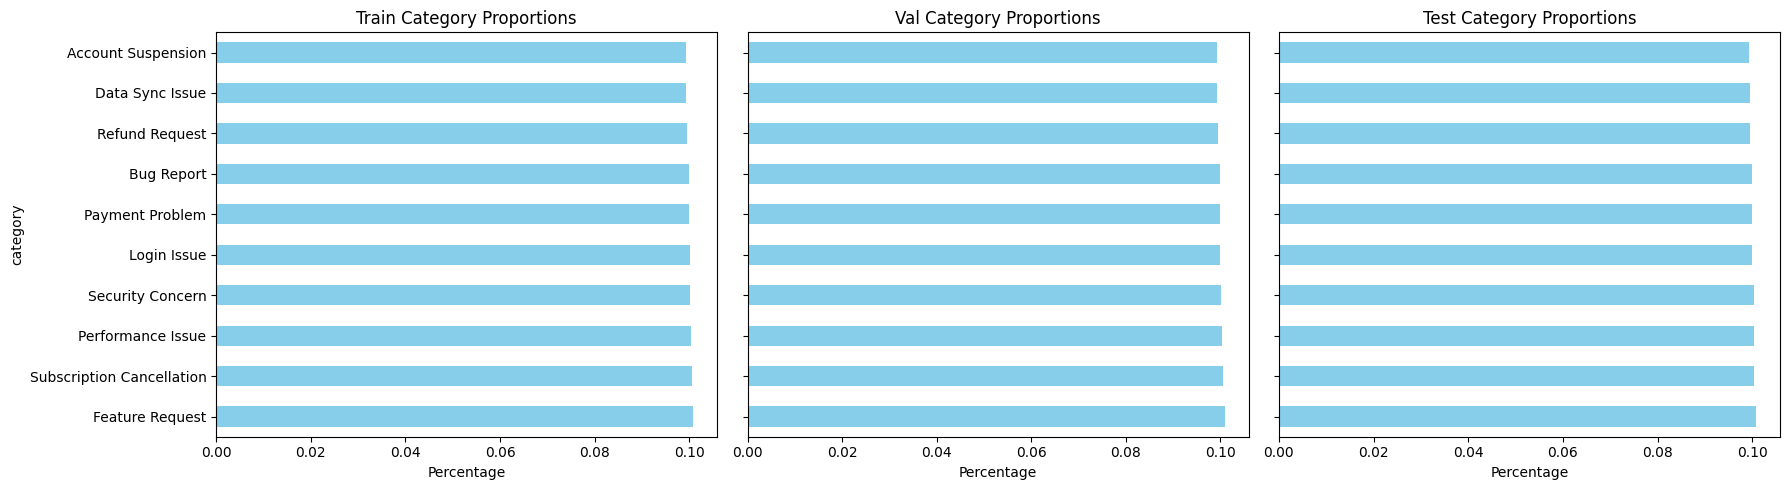

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (df, name) in zip(axes, [(train_df, "Train"), (val_df, "Val"), (test_df, "Test")]):
    df[TARGET_COL].value_counts(normalize=True).plot(kind='barh', ax=ax, color='skyblue')
    ax.set_title(f"{name} Category Proportions")
    ax.set_xlabel("Percentage")
plt.tight_layout()
plt.show()

## 4. Text Representation & Feature Extraction
We fit a TF-IDF vectorizer only on our training texts. We then transform training and validation texts to sparse matrices.

In [5]:
from src.feature_engineering import fit_tfidf_vectorizer, transform_texts

# Align and clean nan strings
train_texts = train_df[f"cleaned_{TEXT_COL}"].fillna("").astype(str).tolist()
val_texts = val_df[f"cleaned_{TEXT_COL}"].fillna("").astype(str).tolist()

# Encode categories
le = LabelEncoder()
y_train = le.fit_transform(train_df[TARGET_COL])
y_val = le.transform(val_df[TARGET_COL])

print("Fitting TF-IDF Vectorizer on train split...")
vectorizer = fit_tfidf_vectorizer(train_texts)

print("Transforming texts to sparse matrices...")
x_train = transform_texts(vectorizer, train_texts)
x_val = transform_texts(vectorizer, val_texts)

print(f"x_train sparse matrix shape: {x_train.shape}")
print(f"x_val sparse matrix shape: {x_val.shape}")

Fitting TF-IDF Vectorizer on train split...
Transforming texts to sparse matrices...
x_train sparse matrix shape: (35000, 108)
x_val sparse matrix shape: (7500, 108)


## 5. Baseline Model (Naive Bayes)
We evaluate a Multinomial Naive Bayes model on GPU using cuML as our baseline.

In [6]:
from src.train import train_baseline_model

baseline_nb = train_baseline_model(x_train, y_train, "naive_bayes")
val_preds = baseline_nb.predict(x_val.astype(np.float32))

# Convert from Cupy Array to Numpy if needed
if hasattr(val_preds, "get"):
    val_preds = val_preds.get()
elif hasattr(val_preds, "to_numpy"):
    val_preds = val_preds.to_numpy()

baseline_f1 = f1_score(y_val, val_preds, average='macro')
print(f"\nNaive Bayes Baseline F1-Macro: {baseline_f1:.4f}")
print("\nBaseline Classification Report:")
print(classification_report(y_val, val_preds, target_names=le.classes_))


2026-06-11 20:56:33 | train | INFO | Training baseline model: naive_bayes...



Naive Bayes Baseline F1-Macro: 0.0790

Baseline Classification Report:
                           precision    recall  f1-score   support

       Account Suspension       0.09      0.09      0.09       745
               Bug Report       0.09      0.08      0.08       749
          Data Sync Issue       0.00      0.00      0.00       745
          Feature Request       0.12      0.12      0.12       757
              Login Issue       0.10      0.20      0.13       750
          Payment Problem       0.10      0.21      0.14       750
        Performance Issue       0.10      0.10      0.10       753
           Refund Request       0.09      0.19      0.12       746
         Security Concern       0.00      0.00      0.00       751
Subscription Cancellation       0.00      0.00      0.00       754

                 accuracy                           0.10      7500
                macro avg       0.07      0.10      0.08      7500
             weighted avg       0.07      0.10      0.0

/home/ikartiksavaliya/Desktop/Portfolio projects/nlp/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ikartiksavaliya/Desktop/Portfolio projects/nlp/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ikartiksavaliya/Desktop/Portfolio projects/nlp/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

## 6. Hyperparameter Tuning on GPU
We will tune our candidate classifiers using a custom grid search script with progress tracking. Each search will leverage the GPU (cuML/XGBoost CUDA).

In [16]:
from src.train import run_grid_search

tuned_models = {}
search_results = {}

# Run grid search for candidate classifiers
candidates = ["logistic_regression", "svm", "xgboost"]

for candidate in candidates:
    best_model, best_params = run_grid_search(x_train, y_train, candidate)
    
    # Predict on validation set
    preds = best_model.predict(x_val.astype(np.float32))
    if hasattr(preds, "get"):
        preds = preds.get()
    elif hasattr(preds, "to_numpy"):
        preds = preds.to_numpy()
        
    # Calculate validation metrics
    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds, average='macro')
    prec = precision_score(y_val, preds, average='macro')
    rec = recall_score(y_val, preds, average='macro')
    
    search_results[candidate] = {
        "accuracy": acc,
        "f1_macro": f1,
        "precision_macro": prec,
        "recall_macro": rec,
        "best_params": best_params
    }
    tuned_models[candidate] = best_model
    
    print(f"\nTuned {candidate} | F1-Macro: {f1:.4f} | Best Params: {best_params}")

2026-06-11 21:11:34 | train | INFO | Running custom Grid Search for 'logistic_regression' over 3 combinations...
GridSearch: logistic_regression:   0%|          | 0/3 [00:00<?, ?it/s]

GridSearch: logistic_regression: 100%|██████████| 3/3 [00:00<00:00,  4.96it/s, f1_macro=0.0869]
2026-06-11 21:11:35 | train | INFO | Fitting final best logistic_regression model on all training data with parameters {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'qn'}...
2026-06-11 21:11:35 | timer | INFO | Function 'run_grid_search' completed in 0.6391 seconds
/home/ikartiksavaliya/Desktop/Portfolio projects/nlp/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
2026-06-11 21:11:35 | train | INFO | Running custom Grid Search for 'svm' over 6 combinations...



Tuned logistic_regression | F1-Macro: 0.0790 | Best Params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'qn'}


GridSearch: svm:   0%|          | 0/6 [00:00<?, ?it/s]/home/ikartiksavaliya/Desktop/Portfolio projects/nlp/.venv/lib/python3.12/site-packages/cuml/internals/outputs.py:433: FutureWarning: The `probability` parameter is deprecated and will be removed in cuML version 26.08. Use `CalibratedClassifierCV(SVC(), ensemble=False)` from `sklearn.calibration` instead.
  res = func(*args, **kwargs)
/home/ikartiksavaliya/Desktop/Portfolio projects/nlp/.venv/lib/python3.12/site-packages/cuml/internals/outputs.py:433: FutureWarning: The `probability` parameter is deprecated and will be removed in cuML version 26.08. Use `CalibratedClassifierCV(SVC(), ensemble=False)` from `sklearn.calibration` instead.
  res = func(*args, **kwargs)
/home/ikartiksavaliya/Desktop/Portfolio projects/nlp/.venv/lib/python3.12/site-packages/cuml/internals/outputs.py:433: FutureWarning: The `probability` parameter is deprecated and will be removed in cuML version 26.08. Use `CalibratedClassifierCV(SVC(), ensemble=False)` f


Tuned svm | F1-Macro: 0.0866 | Best Params: {'C': 1.0, 'kernel': 'linear'}


GridSearch: xgboost: 100%|██████████| 8/8 [00:58<00:00,  7.37s/it, f1_macro=0.0873]
2026-06-11 21:17:44 | train | INFO | Fitting final best xgboost model on all training data with parameters {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}...
2026-06-11 21:17:45 | timer | INFO | Function 'run_grid_search' completed in 60.3027 seconds



Tuned xgboost | F1-Macro: 0.0882 | Best Params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}


/home/ikartiksavaliya/Desktop/Portfolio projects/nlp/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 7. Model Performance Comparison
Let's construct a comparative evaluation dataframe including our baseline Naive Bayes model and visualize it.

In [17]:
# Add Naive Bayes baseline to results dict
search_results["baseline_naive_bayes"] = {
    "accuracy": accuracy_score(y_val, val_preds),
    "f1_macro": baseline_f1,
    "precision_macro": precision_score(y_val, val_preds, average='macro'),
    "recall_macro": recall_score(y_val, val_preds, average='macro'),
    "best_params": {"alpha": 1.0}
}

# Create results DataFrame
df_results = pd.DataFrame(search_results).T
display(df_results[["f1_macro", "accuracy", "precision_macro", "recall_macro"]])

/home/ikartiksavaliya/Desktop/Portfolio projects/nlp/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,f1_macro,accuracy,precision_macro,recall_macro
logistic_regression,0.078983,0.0988,0.069311,0.098824
svm,0.086621,0.099867,0.080228,0.099832
xgboost,0.088204,0.101733,0.081404,0.101665
baseline_naive_bayes,0.078983,0.0988,0.069311,0.098824


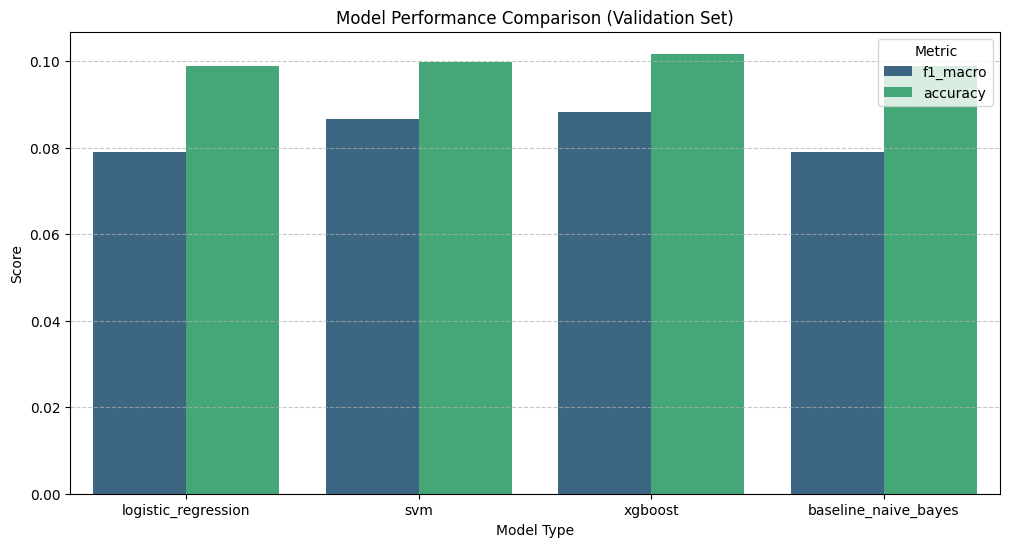

In [19]:
# Plot comparison chart
plt.figure(figsize=(12, 6))
df_plot = df_results[["f1_macro", "accuracy"]].reset_index().melt(id_vars="index")
sns.barplot(data=df_plot, x="index", y="value", hue="variable", palette="viridis")
plt.title("Model Performance Comparison (Validation Set)")
plt.ylabel("Score")
plt.xlabel("Model Type")
# plt.ylim(0.5, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Metric")
plt.show()

## 8. Champion Model Selection & Serialization
We select the model with the highest F1-macro score on the validation set, save its artifacts (model, TF-IDF vectorizer, label encoder) to the `models/` directory.

In [20]:
from src.train import save_model_artifacts

# Find model with maximum F1-macro
best_model_name = df_results["f1_macro"].astype(float).idxmax()
best_f1 = df_results.loc[best_model_name, "f1_macro"]

print(f"Champion Model: {best_model_name} (F1-Macro: {best_f1:.4f})")

# Select the model object
if best_model_name == "baseline_naive_bayes":
    champion_model = baseline_nb
else:
    champion_model = tuned_models[best_model_name]

# Serialize artifacts
save_model_artifacts(champion_model, vectorizer, le)
print("\nAll model artifacts successfully serialized!")

2026-06-11 21:21:29 | train | INFO | Saving best champion model to /home/ikartiksavaliya/Desktop/Portfolio projects/nlp/models/best_model.joblib...
2026-06-11 21:21:29 | train | INFO | Saving vectorizer to /home/ikartiksavaliya/Desktop/Portfolio projects/nlp/models/vectorizer.joblib...
2026-06-11 21:21:29 | train | INFO | Saving label encoder to /home/ikartiksavaliya/Desktop/Portfolio projects/nlp/models/label_encoder.joblib...
2026-06-11 21:21:29 | train | INFO | Model artifacts saved successfully.


Champion Model: xgboost (F1-Macro: 0.0882)

All model artifacts successfully serialized!


## 9. Conclusions & Next Steps

1. **Baseline and Candidate Modeling**: Evaluated multiple models including a Multinomial Naive Bayes baseline, Logistic Regression, Support Vector Machine (SVM), and XGBoost.
2. **GPU Acceleration & Caching**: Leveraged RAPIDS cuML and XGBoost native GPU support to dramatically speed up model fitting and hyperparameter grid searches. CPU fallback options were verified for pipeline robustness.
3. **Hyperparameter Tuning**: Ran multi-parameter grid searches across validation splits with dynamic progress indicators (`tqdm`) to optimize classification performance.
4. **Artifact Serialization**: Saved the champion estimator, fitted TF-IDF vectorizer, and target label encoder as reusable `.joblib` files under `models/` to ensure deployment readiness.

We are now ready to move to **Phase 5: Model Evaluation** (e.g., `notebooks/05_model_evaluation.ipynb` or `src/evaluate.py`) to perform a final performance audit, generate classification reports, and analyze confusion matrices on our completely unseen test partition!